In [6]:
#Copyright (c) 2023 John Simonis and The Ohio State University. All rights reserved.
#This code was written by John Simonis for a research project at The Ohio State University.

#This is what we use for our equations of best fit.
from pysr import PySRRegressor

#Necessary for handling symbolic outputs of pysr.
import sympy

#Let us import data into a dataframe.
import pandas as pd

#Arrays, interpolation, and analysis.
import numpy as np

#Needed for plotting.
from matplotlib import pyplot as plt

#Needed for data skew.
import scipy as sp

#This is a dictionary of a handful of customized PYSR terms, see here https://astroautomata.com/PySR/
default_pysr_params = dict(
    populations=50,
    model_selection="accuracy",
    population_size=100,
    niterations=100,
    binary_operators=["+", "*", "^"],
    unary_operators=["sin", "cos", "exp", "log", "erf", "ceil", "floor"],
    maxsize=50,
    ncycles_per_iteration=100,
    progress=False,
    procs=10,
    variable_names=["x", "y"],
)

#Control Dataset
Control_XLS = pd.ExcelFile("../Control/DessicantControlTests.xlsx")
Control_Dataframe = pd.read_excel(Control_XLS, sheet_name="Average")

#Proto Dataset
Proto_XLS = pd.ExcelFile("../Proto/ProtoTests.xlsx")
Proto_Dataframe = pd.read_excel(Proto_XLS, sheet_name="Average")

#Dep Control Dataset
DepControl_XLS = pd.ExcelFile("../Deprecated/DCTests.xlsx")
DepControl_Dataframe = pd.read_excel(
    DepControl_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)

#Dep Proto Dataset
DepProto_XLS = pd.ExcelFile("../Deprecated/DPTests.xlsx")
DepProto_Dataframe = pd.read_excel(
    DepProto_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)


#Control Variables
C_x = Control_Dataframe["Time (s)"].to_numpy().reshape(-1, 1)
C_y = Control_Dataframe["Water Level (mL)"].to_numpy()
C_z = Control_Dataframe["Temp (C)"].to_numpy()

#Proto Variables
P_x = Proto_Dataframe["Time (s)"].to_numpy().reshape(-1, 1)
P_y = Proto_Dataframe["Water Level (mL)"].to_numpy()
P_z = Proto_Dataframe["Temp (C)"].to_numpy()

#Dep Control Variables
DC_x = (
    pd.to_numeric(
        DepControl_Dataframe["WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DC_y = pd.to_numeric(DepControl_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DC_z = pd.to_numeric(DepControl_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

#Dep Proto Variables
DP_x = (
    pd.to_numeric(
        DepProto_Dataframe["WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DP_y = pd.to_numeric(DepProto_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DP_z = pd.to_numeric(DepProto_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

def analysis(data):
    data_headers = ["Vertical Power", "Vertical Temp", "Vertical Amp", "Vertical Water"]
    for i in range(0, 4):
        print(data_headers[i], "STDDEV:", np.std(data[i]))
        print(data_headers[i], "MEDIAN:", np.median(data[i]))
        print(data_headers[i], "SKEW:", sp.stats.skew(data[i]), "\n")

## Dessicant Wheel Control
The Control Water Harvester utilizes a desiccant wheel design, leveraging a heat lamp to dry out pockets of desiccant and a fan to circulate heated air through the silica gel desiccant.

In [7]:
#Pass in the fitting parameters
Control_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Control_Equations.fit(C_x, C_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.950e+05
Head worker occupation: 16.5%
Progress: 1246 / 5000 total iterations (24.920%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           1.071e+06  1.594e+01  y = x₀
2           1.308e+01  1.130e+01  y = log(x₀)
3           1.614e-01  4.395e+00  y = x₀ * 0.0084499
4           1.586e-01  1.700e-02  y = ceil(x₀ * 0.0080356)
5           1.019e-01  4.422e-01  y = (x₀ + 60.851) * 0.0080432
6           1.019e-01  1.788e-07  y = 0.0080431 * (60.863 + ceil(x₀))
7           9.642e-02  5.578e-02  y = ((x₀ + 95.272) ^ 1.0264) * 0.0064548
8           8.939e-02  7.572e-02  y = ((x₀ + 83.736) ^ 1.0655) * sin(0.0049115)
9           6.131e-02  3.770e-01  y = (x₀ * ((8.366e-07 * x₀) + 0.0065284)) + 0.94934
11          5.638e-02  4.189e-02  y = (118.25 + x₀) * (0.0070487 + (6.2412e-09 * (x₀ ^ 1.5995)))
12          5.638e-02  1.061e-05  y = (118.25 + x

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                          0.6293175   
	1         1.656643e+00                                            log(x0)   
	2         4.394825e+00                                  x0 * 0.0084498925   
	3         1.699964e-02                             ceil(x0 * 0.008035553)   
	4         4.421706e-01                     (60.869755 + x0) * 0.008043003   
	5         1.896265e-01      0.0015185256 * ((222.16599 + x0) ^ 1.2113187)   
	6         5.104384e-04  floor((222.16594 + x0) ^ 1.2102519) * 0.001530...   
	7         1.287813e-01  (((x0 * 8.36535e-7) + 0.0065289815) * x0) + 0....   
	8         4.188651e-02  (118.249245 + x0) * (0.00704874 + (6.241163e-9...   
	9         1.306064e-01  (x0 * ((1.2076772e-6 * x0) + 0.0054683713)) + ...   
	10        1.181253e-01  (((x0 * 4.0405394e-7) + -0.0036688626) * (x0 *...   
	11        8.858474e-04  (x0 * 0.030519858) + ((-0.0036279159 + (3.9975...   
	12        1.394075e-02  0.15112248 + (((x0 * log(x0)) * (-0.0031563295...   
	13        5.621292e-04  0.15112248 + ((ceil(x0 * log(x0)) * (-0.003156...   
	14        4.017809e-03  (floor((0.0007749514 * x0) + x0) * 0.031197602...   
	15        1.630826e-02  (((x0 + (log(x0) * x0)) ^ erf(0.02927182 * x0)...   
	16        8.312862e-04  ((floor(x0 + (log(x0) * x0)) ^ erf(0.02927182 ...   
	17        3.529924e-04  (ceil(floor((x0 + (log(x0) * x0)) ^ erf(0.0292...   
	18        2.416352e-03  (ceil((x0 + (log(x0) * x0)) ^ erf((0.034664582...   
	19        1.915131e-04  (ceil((x0 + (log(x0) * x0)) ^ erf((0.034664582...   
	20        6.191319e-04  (((-0.005779135 + (x0 * 5.658641e-7)) * 0.6313...   
	21        1.466342e-04  (((floor(x0 + (log(x0) * x0)) ^ erf((0.0346645...   
	22        8.717396e-04  ((((x0 + ceil(log(x0) * x0)) ^ erf((0.03466458...   
	23        2.538002e-03  ((((x0 + (log(x0) * x0)) ^ erf((0.034664582 * ...   
	24        7.119809e-07  ((((x0 + (log(x0) * x0)) ^ erf((0.034664582 * ...   
	25  >>>>  8.395317e-04  ((((x0 + (log(x0) * x0)) ^ erf((0.034664582 * ...   
	
	         loss  complexity  
	0   68.536220           1  
	1   13.075224           2  
	2    0.161362           3  
	3    0.158642           4  
	4    0.101950           5  
	5    0.069772           7  
	6    0.069736           8  
	7    0.061310           9  
	8    0.056383          11  
	9    0.049479          12  
	10   0.039068          14  
	11   0.039033          15  
	12   0.038493          16  
	13   0.038471          17  
	14   0.038164          19  
	15   0.036939          21  
	16   0.036908          22  
	17   0.036895          23  
	18   0.036806          24  
	19   0.036792          26  
	20   0.036746          28  
	21   0.036736          30  
	22   0.036704          31  
	23   0.036518          33  
	24   0.036518          34  
	25   0.036487          35  
]

Vertical Power STDDEV: 0.003055499438317472
Vertical Power MEDIAN: 0.5133333333333333
Vertical Power SKEW: 0.1908440289314235 

Vertical Temp STDDEV: 2.9918445133812783
Vertical Temp MEDIAN: 27.08
Vertical Temp SKEW: 0.00830511957701228 

Vertical Amp STDDEV: 0.023454447576336378
Vertical Amp MEDIAN: 7.713333333333334
Vertical Amp SKEW: -0.10235233214597493 

Vertical Water STDDEV: 4.191422343549114
Vertical Water MEDIAN: 7.333333333333333
Vertical Water SKEW: 0.13485310695774946 

\left(3.57 \cdot 10^{-7} x_{0} - 0.00365\right) \left(\left(x_{0} \log{\left(x_{0} \right)} + x_{0}\right)^{\operatorname{erf}{\left(0.0579 x_{0} - 1.25 \right)}} + e^{\sin{\left(0.00804 x_{0} \right)}}\right) + 0.0343 \left\lceil{x_{0}}\right\rceil


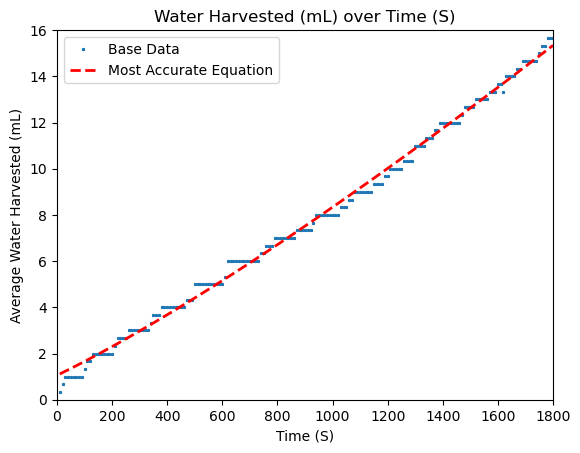

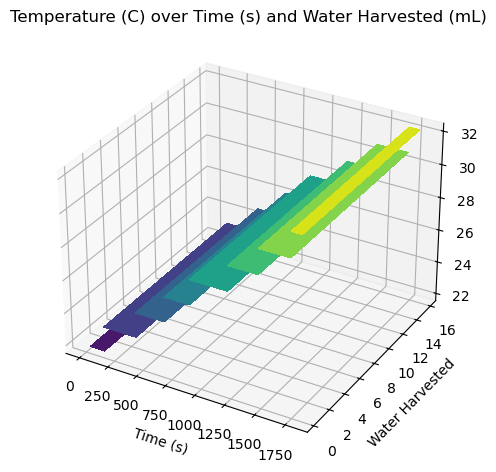

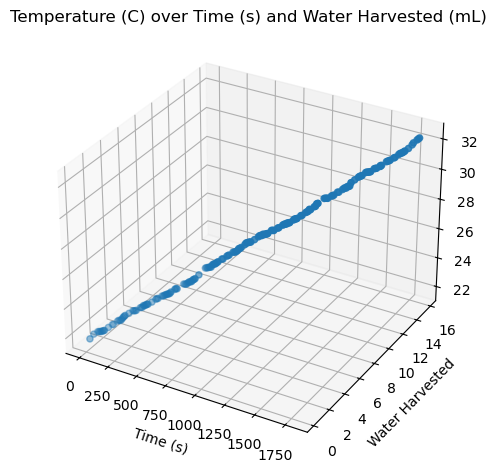

In [8]:
#Basic scatter plot
plt.plot(
    C_x,
    C_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Control_Equations.equations_.query(
    f"loss < {2 * Control_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    C_x,
    Control_Equations.predict(C_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Time (s)")
plt.xlabel("Time (S)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 1800])
plt.ylim([0, 16])
analysis(
    [
        Control_Dataframe["WattHours (WH)"].to_numpy(),
        C_z,
        Control_Dataframe["Amps (A)"].to_numpy(),
        C_y,
    ]
)
print(Control_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Time (s) and Water Harvested (mL)")
plt.xlabel("Time (s)")
plt.ylabel("Water Harvested")
fig.tight_layout()
C_X, C_Y = np.meshgrid(C_x,C_y)
C_Z = sp.interpolate.griddata(np.column_stack((C_x.reshape(-1,1),C_y)), C_z, (C_X, C_Y), method = "nearest")
plt.contourf(C_x.reshape(-1),C_y,C_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Time (s) and Water Harvested (mL)")
plt.xlabel("Time (s)")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(C_x,C_y,C_z)

# NiTi Prototype
The NiTi prototype employs a straightforward gantry system, powered by a high torque stepper motor. A T8 leadscrew is incorporated for a simple mechanical advantage to apply stress to the NiTi wires.

In [9]:
#Run PySR
Proto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Proto_Equations.fit(P_x, P_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 5.550e+05
Head worker occupation: 13.6%
Progress: 1264 / 5000 total iterations (25.280%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           6.086e+00  7.971e+00  y = log(x₀)
3           7.275e-02  4.427e+00  y = x₀ * 0.0052855
5           3.991e-02  3.003e-01  y = (x₀ * 0.0064822) ^ 0.90381
6           3.991e-02  1.073e-06  y = (sin(0.0064822) * x₀) ^ 0.90381
7           3.747e-02  6.294e-02  y = (0.0059829 + (x₀ * -5.1513e-07)) * x₀
8           3.747e-02  5.960e-08  y = sin(0.0059828 + (-5.1505e-07 * x₀)) * x₀
9           3.743e-02  9.528e-04  y = (0.0059531 + (x₀ * -5.005e-07)) * (x₀ + 2.2374)
11          3.738e-02  7.689e-04  y = (0.0066112 + (-5.7093e-07 * x₀)) * floor(ceil(x₀) * 0.9057...
                                  6)
12          3.588e-02  4.075e-02  y = (0.0071704 + (ceil((x₀ ^ 0.3605) + 0.93151) * -0.00012787)...
        

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          0.9956135   
	1         1.276772                                            log(x0)   
	2         4.426739                                  x0 * 0.0052855494   
	3         0.300365                     (0.006468008 * x0) ^ 0.9047106   
	4         0.031369          x0 * ((x0 * -5.1511273e-7) + 0.005982865)   
	5         0.010213     ((x0 * -1.0000006) + (0.0060719214 + x0)) * x0   
	6         0.038417  floor(x0 * -0.09617663) * ((4.9906184e-6 * x0)...   
	7         0.007078  floor(floor(-0.09610532 * x0)) * ((4.9355667e-...   
	8         0.085070  x0 * ((0.00131229 * sin(ceil(x0 * 0.0013154744...   
	9         0.000290  ((sin(-0.43516842 * ceil(0.001315064 * x0)) * ...   
	10        0.000600  x0 * ((0.00131224 * sin(ceil((0.0013152591 * x...   
	11        0.000496  ((0.0013151962 * sin(ceil(0.0013151962 * x0) *...   
	12        0.004425  ((sin(ceil((sin(0.0013156995) * (x0 + 0.181195...   
	13        0.027048  (0.0063563306 + (sin(-0.46367443 * ceil(0.0013...   
	14        0.014405  (0.0063563306 + (sin(-0.46367443 * ceil(0.0013...   
	15        0.000004  (sin(0.0063563306) + (sin(-0.46367443 * ceil(0...   
	16        0.001328  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	17        0.001860  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	18        0.000796  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	19        0.000488  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	20        0.004451  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	21        0.004900  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	22        0.005824  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	23        0.000576  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	24        0.003152  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	25  >>>>  0.007038  (0.0063563306 + (0.0013117832 * sin(-0.4636744...   
	
	         loss  complexity  
	0   21.819029           1  
	1    6.086116           2  
	2    0.072750           3  
	3    0.039897           5  
	4    0.037471           7  
	5    0.036713           9  
	6    0.035329          10  
	7    0.035080          11  
	8    0.029592          13  
	9    0.029575          15  
	10   0.029557          16  
	11   0.029528          18  
	12   0.029397          19  
	13   0.028613          20  
	14   0.028203          21  
	15   0.028203          22  
	16   0.028166          23  
	17   0.028114          24  
	18   0.028091          25  
	19   0.028078          26  
	20   0.027953          27  
	21   0.027816          28  
	22   0.027655          29  
	23   0.027639          30  
	24   0.027552          31  
	25   0.027359          32  
]

Vertical Power STDDEV: 0.2785496658115589
Vertical Power MEDIAN: 0.27
Vertical Power SKEW: 0.0014724439344308453 

Vertical Temp STDDEV: 0.14768078479453892
Vertical Temp MEDIAN: 23.511666666666663
Vertical Temp SKEW: -0.04108905149599962 

Vertical Amp STDDEV: 4.179428089587817
Vertical Amp MEDIAN: 4.045
Vertical Amp SKEW: 0.0012824667441691305 

Vertical Water STDDEV: 2.6305658218736663
Vertical Water MEDIAN: 5.0
Vertical Water SKEW: -0.11995470090320919 

\left(0.00131 \sin{\left(- 0.464 \left\lceil{0.00131 x_{0}}\right\rceil \right)} + 0.00636\right) \left(x_{0} + \left\lfloor{e^{\left\lceil{\left\lfloor{e^{\operatorname{erf}{\left(\sin{\left(\sin{\left(\sin{\left({1.02}^{x_{0}} \right)} \right)} 1.71 \right)} \right)}}}\right\rfloor + 0.745}\right\rceil}}\right\rfloor - 1.01\right)


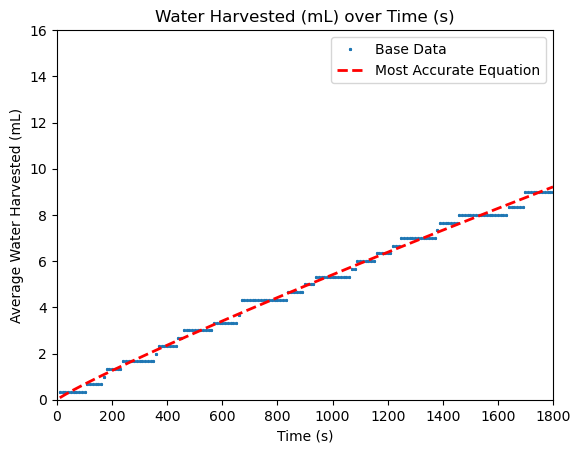

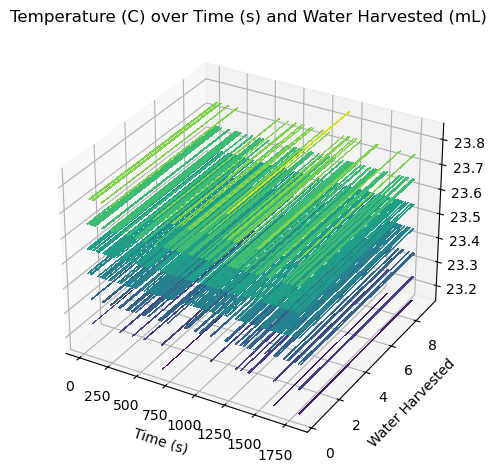

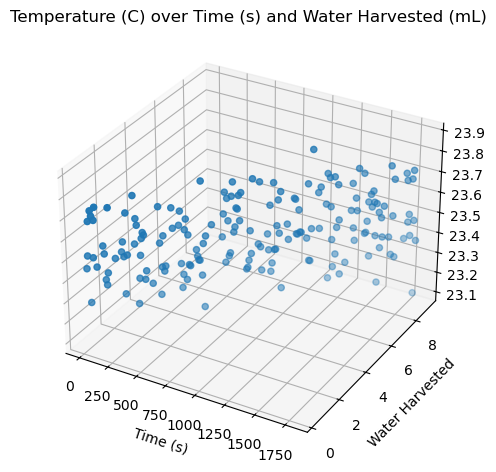

In [10]:
#Basic scatter plot
plt.plot(
    P_x,
    P_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Proto_Equations.equations_.query(
    f"loss < {2 * Proto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    P_x,
    Proto_Equations.predict(P_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Time (s)")
plt.xlabel("Time (s)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 1800])
plt.ylim([0, 16])
analysis(
    [
        Proto_Dataframe["WattHours (WH)"].to_numpy(),
        P_z,
        Proto_Dataframe["Amps (A)"].to_numpy(),
        P_y,
    ]
)
print(Proto_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Time (s) and Water Harvested (mL)")
plt.xlabel("Time (s)", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
P_X, P_Y = np.meshgrid(P_x,P_y)
P_Z = sp.interpolate.griddata(np.column_stack((P_x.reshape(-1,1),P_y)), P_z, (P_X, P_Y), method = "nearest")
plt.contourf(P_x.reshape(-1),P_y,P_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Time (s) and Water Harvested (mL)")
plt.xlabel("Time (s)")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(P_x,P_y,P_z)

# Deprecated Designs
The Peltier device is first and then the first NiTi prototype is second.

In [11]:
#Run PySR
DepControl_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepControl_Equations.fit(DC_x,DC_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.220e+05
Head worker occupation: 25.8%
Progress: 838 / 5000 total iterations (16.760%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           7.138e+00  1.594e+01  y = x₀
2           1.189e+00  1.792e+00  y = exp(0.98866)
3           1.189e+00  7.953e-04  y = x₀ ^ -0.71046
4           1.189e+00  6.795e-06  y = erf(x₀) ^ -0.76567
5           1.188e+00  4.292e-06  y = erf(erf(x₀)) ^ -0.82704
6           1.188e+00  3.278e-06  y = (sin(x₀) ^ -0.79321) * 0.88405
7           1.188e+00  4.172e-06  y = x₀ ^ (-0.80087 + (x₀ * 0.36372))
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 2.300e+05
Head worker occupation: 26.3%
Progress: 1774 / 5000 total iterations (35.480%)
Hall of Fame:
----------------------------

PySRRegressor.equations_ = [
	   pick         score                             equation      loss  \
	0        0.000000e+00                                   x0  7.138098   
	1        1.791950e+00                      exp(0.98865587)  1.189457   
	2        7.953008e-04                     x0 ^ -0.71045923  1.188511   
	3        6.983551e-06                 erf(x0) ^ -0.7656679  1.188503   
	4        1.076991e-05      -0.29235464 + (x0 ^ -0.7846196)  1.188490   
	5        1.262106e-06  log(0.7910202) + (x0 ^ -0.77049243)  1.188489   
	6  >>>>  8.414048e-08   x0 ^ (-0.8008744 + (x0 * 0.36372))  1.188489   
	
	   complexity  
	0           1  
	1           2  
	2           3  
	3           4  
	4           5  
	5           6  
	6           7  
]

Vertical Power STDDEV: 0.003346364051814961
Vertical Power MEDIAN: 0.25
Vertical Power SKEW: -2.2203703729531203 

Vertical Temp STDDEV: 0.10611890293381486
Vertical Temp MEDIAN: 22.8
Vertical Temp SKEW: -0.10926708348002251 

Vertical Amp STDDEV: 0.027706118013451422
Vertical Amp MEDIAN: 3.73
Vertical Amp SKEW: 0.06975514771080801 

Vertical Water STDDEV: 1.0906223289417172
Vertical Water MEDIAN: 3.0
Vertical Water SKEW: -0.7987799534398714 

x_{0}^{x_{0} \cdot 0.364 - 0.801}


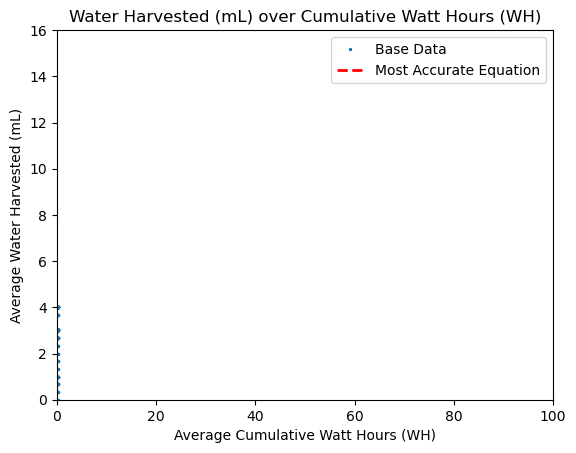

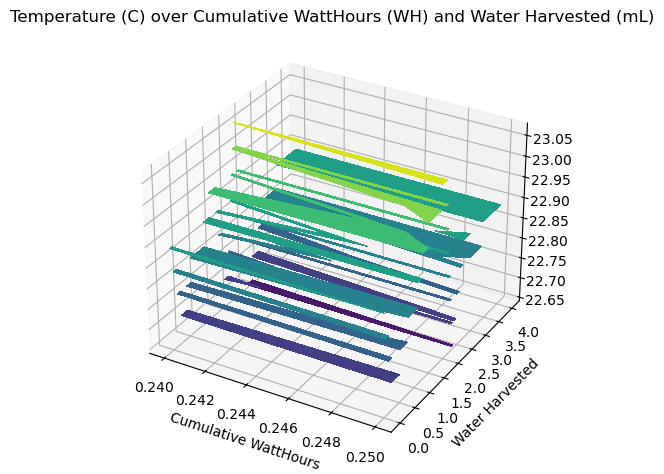

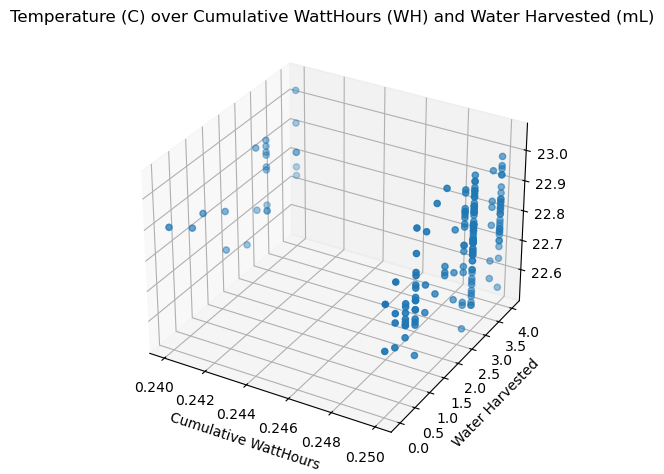

In [12]:
#Basic scatter plot
plt.plot(
    DC_x,
    DC_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepControl_Equations.equations_.query(
    f"loss < {2 * DepControl_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DC_x,
    DepControl_Equations.predict(DC_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        pd.to_numeric(
            DepControl_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_z,
        pd.to_numeric(
            DepControl_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_y,
    ]
)
print(DepControl_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DC_X, DC_Y = np.meshgrid(DC_x,DC_y)
DC_Z = sp.interpolate.griddata(np.column_stack((DC_x.reshape(-1,1),DC_y)), DC_z, (DC_X, DC_Y), method = "nearest")
plt.contourf(DC_x.reshape(-1),DC_y,DC_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DC_x,DC_y,DC_z)

In [13]:
#Run PySR
DepProto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepProto_Equations.fit(DP_x,DP_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.240e+05
Head worker occupation: 27.0%
Progress: 927 / 5000 total iterations (18.540%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           9.160e+00  1.594e+01  y = x₀
2           2.098e+00  1.474e+00  y = exp(1.1308)
4           2.097e+00  2.629e-04  y = 3.492 ^ cos(x₀)
6           2.087e+00  2.325e-03  y = floor(ceil(exp(x₀ ^ -0.10453)))
7           2.079e+00  4.090e-03  y = 0.087106 + ceil(exp(x₀ ^ -0.10453))
9           2.079e+00  6.884e-06  y = 0.092456 + ceil(exp((x₀ + x₀) ^ -0.43239))
15          2.074e+00  3.571e-04  y = erf(erf(cos(sin(sin(exp(x₀ + exp(0.39753 + 1.3714))))))) *...
                                   exp(1.4723)
16          2.066e+00  3.885e-03  y = cos(erf(cos(erf(sin(exp((3.3722 + x₀) * exp(cos(x₀))))))))...
                                   * exp(1.4358)
19          2.057e+00  1.548e-03  y = exp(1.4723) * erf

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                                 x0   
	1         1.473743                                     exp(1.1307548)   
	2         0.002588                             floor(x0 ^ -1.5477982)   
	3         0.001598                 floor(x0 ^ -1.5477982) * 1.0155101   
	4         0.001329            ceil(exp(x0 ^ -0.10453189)) ^ 1.0290234   
	5         0.000931  (-1.6460358 + ceil(exp((x0 + x0) ^ -0.43239328...   
	6         0.001831  cos(erf(cos(sin(exp((3.3722491 + x0) * exp(x0)...   
	7         0.002877  cos(sin(cos(sin(sin(exp((3.3722491 + x0) * exp...   
	8         0.001212  exp(1.4357586) * cos(sin(cos(erf(sin(exp((3.37...   
	9         0.000024  exp(1.4357586) * cos(sin(cos(erf(sin(exp((3.37...   
	10        0.000032  exp(1.4357586) * cos(erf(cos(sin(sin(exp(exp(c...   
	11        0.000291  exp(1.4357586) * cos(erf(cos(sin(sin(x0 + exp(...   
	12  >>>>  0.000265  exp(1.4039721) * cos(erf(cos(sin(x0 * (exp(cei...   
	
	        loss  complexity  
	0   9.160290           1  
	1   2.098316           2  
	2   2.087482           4  
	3   2.080822           6  
	4   2.078058           7  
	5   2.070336          11  
	6   2.058996          14  
	7   2.053080          15  
	8   2.048111          17  
	9   2.048062          18  
	10  2.047666          24  
	11  2.046474          26  
	12  2.044846          29  
]

Vertical Power STDDEV: 0.014679880518742925
Vertical Power MEDIAN: 0.44
Vertical Power SKEW: -0.09197059749850972 

Vertical Temp STDDEV: 0.15856514246117498
Vertical Temp MEDIAN: 25.01
Vertical Temp SKEW: -0.0984512551837561 

Vertical Amp STDDEV: 0.21317526595982159
Vertical Amp MEDIAN: 6.61
Vertical Amp SKEW: -0.07791209416425922 

Vertical Water STDDEV: 1.4485566224712627
Vertical Water MEDIAN: 3.33
Vertical Water SKEW: -0.2322940059788474 

4.07 \cos{\left(\operatorname{erf}{\left(\cos{\left(\sin{\left(x_{0} e^{2} e^{e^{2 x_{0}}} \sin{\left(\left\lfloor{\log{\left(\cos{\left(\sin{\left(0.353 x_{0} \right)} \right)} \right)}}\right\rfloor \right)} \right)} + 0.138 \right)} \right)} \right)}


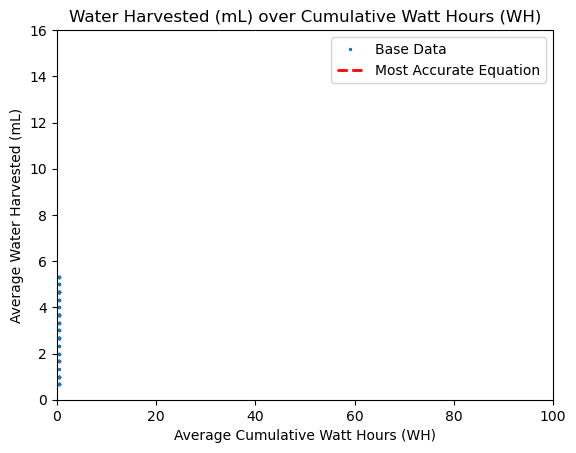

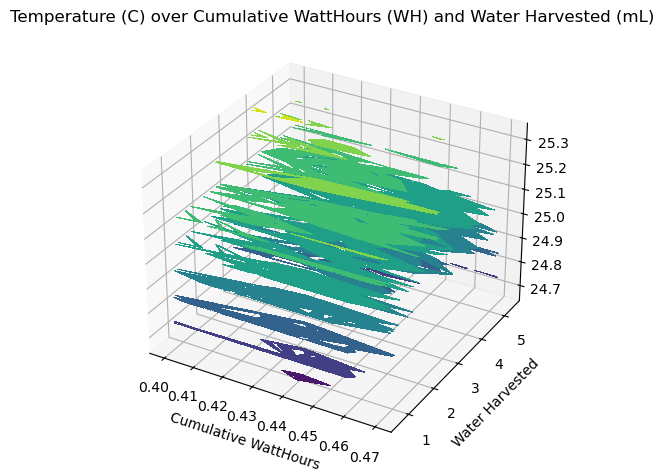

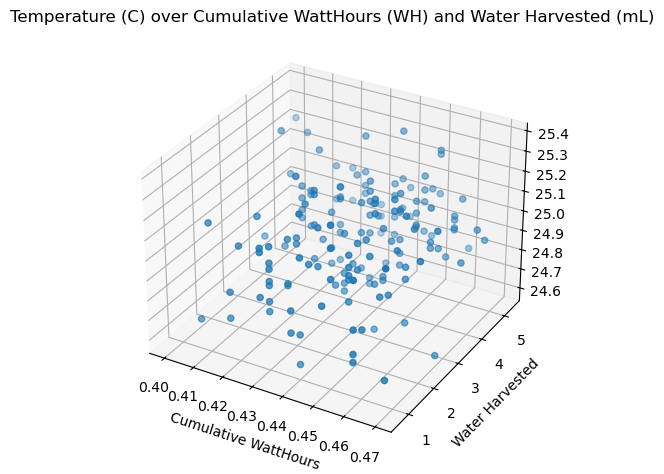

In [14]:
#Basic scatter plot
plt.plot(
    DP_x,
    DP_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepProto_Equations.equations_.query(
    f"loss < {2 * DepProto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DP_x,
    DepProto_Equations.predict(DP_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        pd.to_numeric(
            DepProto_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_z,
        pd.to_numeric(
            DepProto_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_y,
    ]
)
print(DepProto_Equations.latex())

#3D scatterplot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DP_X, DP_Y = np.meshgrid(DP_x,DP_y)
DP_Z = sp.interpolate.griddata(np.column_stack((DP_x.reshape(-1,1),DP_y)), DP_z, (DP_X, DP_Y), method = "nearest")
plt.contourf(DP_x.reshape(-1),DP_y,DP_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DP_x,DP_y,DP_z)